In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import torch
from torch_geometric.data import Data
print(os.getpid())

2767201


In [ ]:
folder_path = "Data"

sequence=[]
distance_map=[]
dca=[]
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        full_path = os.path.join(folder_path, file)
        
        with open(full_path, "rb") as f:
            loaded = pickle.load(f)

        sequence.append(loaded['sequence'])
        distance_map.append(loaded['distance_map'])
        dca.append(loaded['dca'])

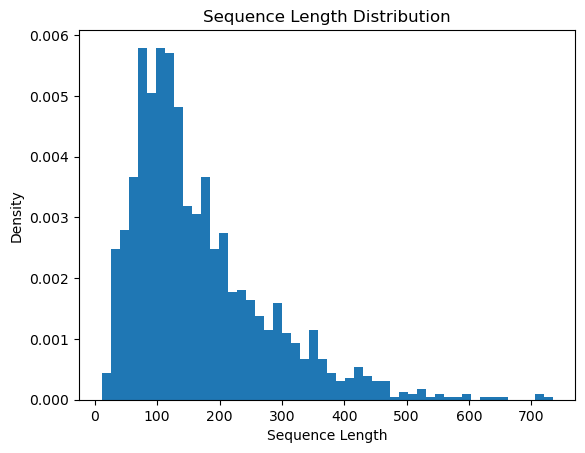

In [3]:
length=[]
for i in range(len(sequence)):
    length.append(len(sequence[i]))

plt.figure()
plt.hist(length, bins=50, density=True)
plt.xlabel("Sequence Length")
plt.ylabel("Density")
plt.title("Sequence Length Distribution")
plt.show()

In [4]:
def contact_from_distance(distance_map, threshold=8.0):
    contact_map = (distance_map < threshold).astype(int)
    return contact_map  


def top_k_mask(matrix, k):
    n = matrix.shape[0]

    # Get upper triangle indices (excluding diagonal)
    triu_indices = np.triu_indices(n, k=1)

    # Extract corresponding values
    values = matrix[triu_indices]

    # Get indices of top-k values
    top_k_idx = np.argpartition(values, -k)[-k:]

    # Create empty mask
    mask = np.zeros_like(matrix, dtype=int)

    # Map back to matrix indices
    rows = triu_indices[0][top_k_idx]
    cols = triu_indices[1][top_k_idx]

    # Set both (i,j) and (j,i) = 1 (since symmetric)
    mask[rows, cols] = 1
    mask[cols, rows] = 1

    return mask

In [6]:
stats=np.zeros((1000,3))


for i in range(len(sequence)):
    seq=sequence[i]
    dist=distance_map[i]
    dca_map=dca[i]

    contact_map = contact_from_distance(dist, threshold=8.0)
    isfinite = np.isfinite(dist)

    k = 5*len(seq)  
    binary_map = top_k_mask(dca_map, k)

    n = binary_map.shape[0]

    for i in range(n):
        for j in range(i+1, n):  # upper triangle only

            d = abs(i - j)

            if isfinite[i][j]:
                stats[d, 2] += 1  # total pairs at distance d

            if binary_map[i, j]==1:

                if contact_map[i, j]==1 and isfinite[i][j]:
                    #true positives
                    stats[d, 0] += 1

                elif contact_map[i, j]==0 and isfinite[i][j]:
                    #false positives
                    stats[d, 1] += 1
tp = stats[:, 0]
fp = stats[:, 1]
total_seen = stats[:, 2]
distances = np.arange(len(stats))
total_percentage = np.where(total_seen > 0, (tp + fp)/ total_seen , 0)
precision = np.where((tp + fp) > 0, tp / (tp + fp), 0)

/tmp/ipykernel_2767201/2215838554.py:38: RuntimeWarning: invalid value encountered in divide
  total_percentage = np.where(total_seen > 0, (tp + fp)/ total_seen , 0)
/tmp/ipykernel_2767201/2215838554.py:39: RuntimeWarning: invalid value encountered in divide
  precision = np.where((tp + fp) > 0, tp / (tp + fp), 0)


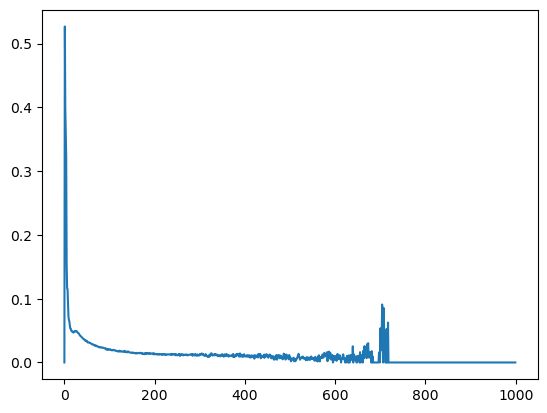

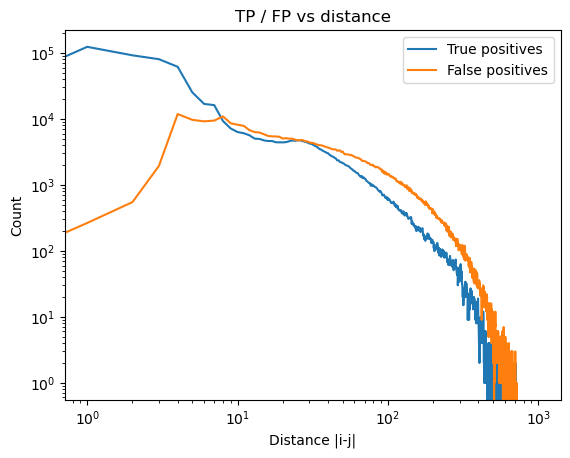

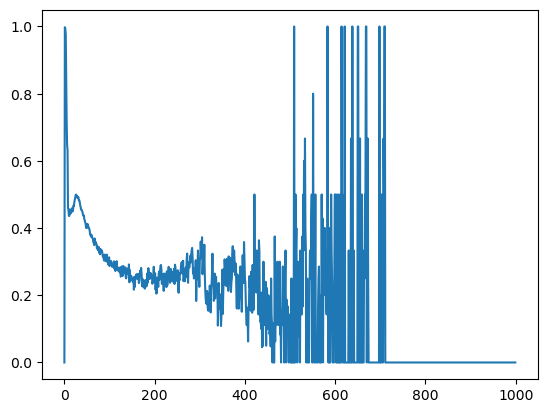

In [8]:
import matplotlib.pyplot as plt
plt.plot(distances, total_percentage, label="Percentage of contacts")
plt.show()


plt.loglog(distances, tp, label="True positives")
plt.loglog(distances, fp, label="False positives")

plt.xlabel("Distance |i-j|")
plt.ylabel("Count")
plt.title("TP / FP vs distance")
plt.legend()
plt.show()

import matplotlib.pyplot as plt
plt.plot(distances, precision, label="Percentage of contacts")
plt.show()


come gestire le code?????????? perchè così in big proteine prendo tutti i contatti buoni distanti

In [13]:
#Let's generalize this to make nice noise

import numpy as np

def remap_contact_map_by_distance(
    contact_map,
    target_contacts_by_d,
    good_fraction_by_d,
    seed=None,
):
    rng = np.random.default_rng(seed)
    contact_map = np.asarray(contact_map)
    n = contact_map.shape[0]

    new_map = np.zeros((n, n), dtype=np.int8)
    selected_good = {}
    selected_bad = {}

    for d in range(1, n):
        total_target = int(target_contacts_by_d[d])
        if total_target <= 0:
            selected_good[d] = 0
            selected_bad[d] = 0
            continue

        good_target = int(round(total_target * good_fraction_by_d[d]))
        good_target = max(0, min(good_target, total_target))
        bad_target = total_target - good_target

        i = np.arange(0, n - d)
        j = i + d

        # pairs at this distance
        real_mask = contact_map[i, j] > 0
        real_i, real_j = i[real_mask], j[real_mask]
        non_i, non_j = i[~real_mask], j[~real_mask]

        if good_target > len(real_i):
            print(f"Distance {d}: need {good_target} good contacts, "
                f"but only {len(real_i)} real contacts exist. Using all available.")
            good_target = len(real_i)
            bad_target = total_target - good_target
            
        if bad_target > len(non_i):
            raise ValueError(
                f"Distance {d}: need {bad_target} bad contacts, "
                f"but only {len(non_i)} non-contacts exist."
            )

        good_idx = rng.choice(len(real_i), size=good_target, replace=False)
        bad_idx = rng.choice(len(non_i), size=bad_target, replace=False)

        gi, gj = real_i[good_idx], real_j[good_idx]
        bi, bj = non_i[bad_idx], non_j[bad_idx]

        new_map[gi, gj] = 1
        new_map[gj, gi] = 1
        new_map[bi, bj] = 1
        new_map[bj, bi] = 1

        selected_good[d] = good_target
        selected_bad[d] = bad_target

    return new_map, selected_good, selected_bad

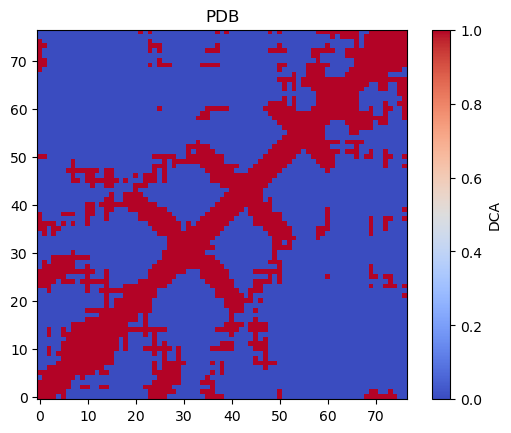

[ 0 59 51 36 37 12 12 12 10  3  6  4  5  4  7  5  2  2  4  2  5  2  4  4
  5  2  6  5  5  2  5  6  4  3  4  4  4  2  4  4  2  0  1  3  4  0  1  5
  1  1  2  2  2  2  0  0  1  2  0  1  0  1  0  0  0  1  0  0  0  0  0  0
  0  0  0  0  0]
Distance 44: need 2 good contacts, but only 1 real contacts exist. Using all available.
Distance 47: need 2 good contacts, but only 1 real contacts exist. Using all available.
Distance 52: need 1 good contacts, but only 0 real contacts exist. Using all available.
Distance 57: need 1 good contacts, but only 0 real contacts exist. Using all available.


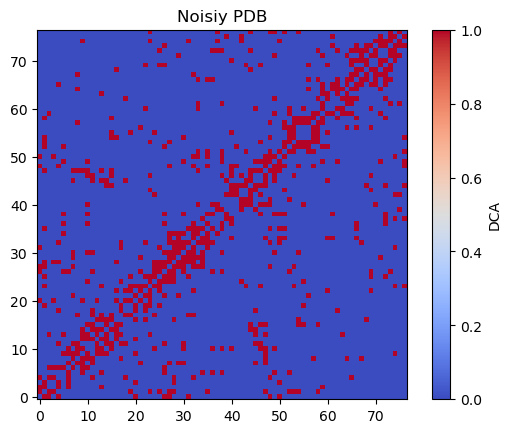

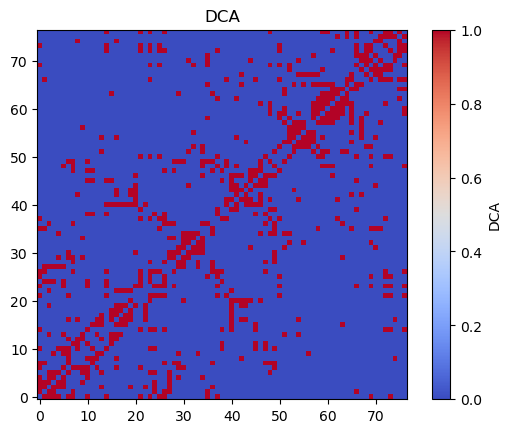

In [22]:
index=3

contact_map=contact_from_distance(distance_map[index])

plt.figure()
plt.imshow(contact_map,cmap='coolwarm', origin='lower')
#plt.imshow(false_positives,cmap='coolwarm_r', origin='lower')
plt.colorbar(label="DCA")
plt.title("PDB")
plt.show()


L = len(contact_map)  # example
K = 5 * L

# distances you consider
distances = np.arange(1, L)

density = total_percentage[:L] 

# number of possible pairs at each distance
N_d = L-distances 

# weights
w = N_d * density[distances]
#print(w)

# normalize to probabilities
P = w / w.sum()
#number of contact needed at each distance
contacts_per_d = np.append(np.array([0]), np.random.multinomial(K, P))

print(contacts_per_d)

#percentage of good contacts needed at each distance
good_fraction_by_d = precision[:L]

new_map, good_counts, bad_counts = remap_contact_map_by_distance(contact_map, contacts_per_d, good_fraction_by_d,seed=1)

plt.figure()
plt.imshow(new_map,cmap='coolwarm', origin='lower')
#plt.imshow(false_positives,cmap='coolwarm_r', origin='lower')
plt.colorbar(label="DCA")
plt.title("Noisiy PDB")
plt.show()


k = 5*len(sequence[index])  
binary_map = top_k_mask(dca[index], k)
plt.figure()
plt.imshow(binary_map,cmap='coolwarm', origin='lower')
#plt.imshow(false_positives,cmap='coolwarm_r', origin='lower')
plt.colorbar(label="DCA")
plt.title("DCA")
plt.show()



